<a href="https://colab.research.google.com/github/almasparwaiz/Hackathon-Projects/blob/main/Titanic_Survival_Prediction_A_Complete_Data_Science_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv('/content/SVMtrain.csv')
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,Male,22.0,1,0,7.2500,3
1,2,1,1,female,38.0,1,0,71.2833,1
2,3,1,3,female,26.0,0,0,7.9250,3
3,4,1,1,female,35.0,1,0,53.1000,3
4,5,0,3,Male,35.0,0,0,8.0500,3


--- Survival Rate by Gender ---
Sex
Male      0.188908
female    0.740385
Name: Survived, dtype: float64


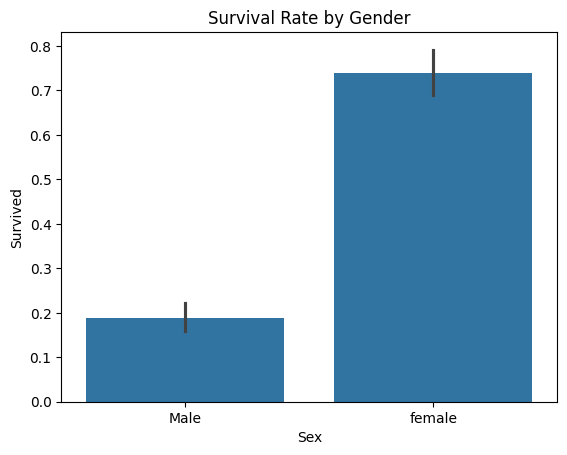


--- Survival Rate by Class ---
Pclass
1    0.626168
2    0.472826
3    0.242363
Name: Survived, dtype: float64


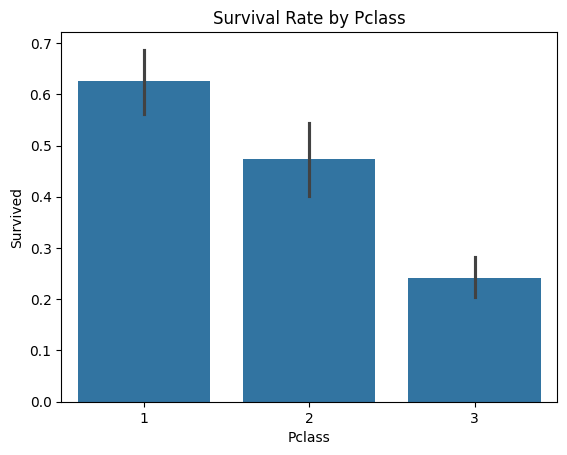


--- Age Distribution ---


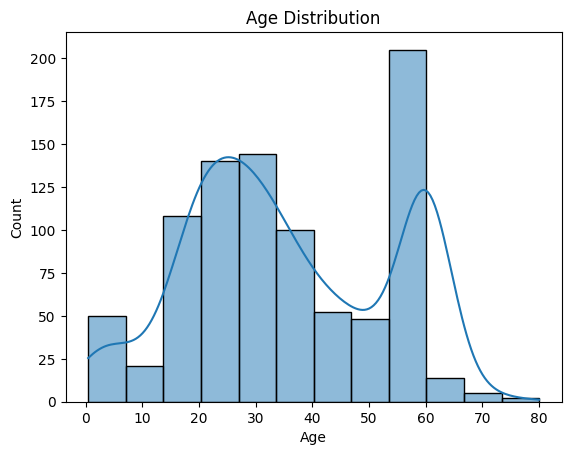

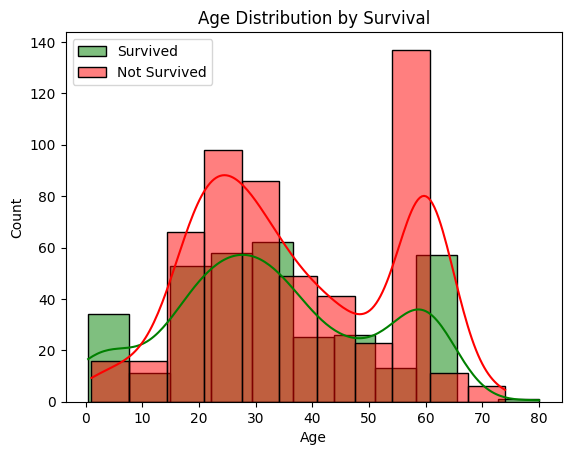


--- Fare vs. Survival ---


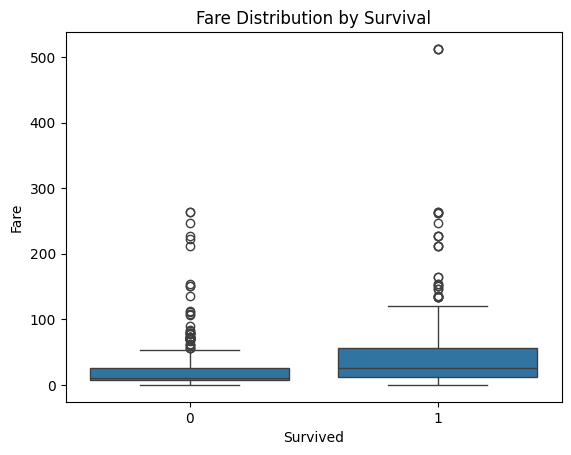

In [18]:
print('--- Survival Rate by Gender ---')
print(df.groupby('Sex')['Survived'].mean())
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')
plt.show()

print('\n--- Survival Rate by Class ---')
print(df.groupby('Pclass')['Survived'].mean())
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Pclass')
plt.show()

print('\n--- Age Distribution ---')
sns.histplot(df['Age'].dropna(), kde=True)
plt.title('Age Distribution')
plt.show()

sns.histplot(df[df['Survived']==1]['Age'].dropna(), kde=True, color='green', label='Survived')
sns.histplot(df[df['Survived']==0]['Age'].dropna(), kde=True, color='red', label='Not Survived')
plt.title('Age Distribution by Survival')
plt.legend()
plt.show()

print('\n--- Fare vs. Survival ---')
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare Distribution by Survival')
plt.show()

In [19]:
print('--- Handling Missing Values ---')

# Handle missing 'Age' values with median imputation
df['Age'].fillna(df['Age'].median(), inplace=True)
print(f"Missing 'Age' values after median imputation: {df['Age'].isnull().sum()}")

# Handle missing 'Embarked' values with mode imputation
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'].fillna(mode_embarked, inplace=True)
print(f"Missing 'Embarked' values after mode imputation: {df['Embarked'].isnull().sum()}")

print('\n--- Dropping Useless Columns ---')
# Drop 'PassengerId' column (since 'Ticket' is not present in this dataset)
df.drop(['PassengerId'], axis=1, inplace=True)
print("Column 'PassengerId' dropped.")

print('\n--- DataFrame Info After Cleaning ---')
df.info()

--- Handling Missing Values ---
Missing 'Age' values after median imputation: 0
Missing 'Embarked' values after mode imputation: 0

--- Dropping Useless Columns ---
Column 'PassengerId' dropped.

--- DataFrame Info After Cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 55.7+ KB


/tmp/ipykernel_708/4193576427.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_708/4193576427.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [20]:
# 1. Family Size and Alone
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['Alone'] = (df['FamilySize'] == 1).astype(int)

# 2. Fare Per Person
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

# 3. Age Groups
bins = [0, 16, 60, df['Age'].max() + 1] # Child (0-15), Adult (16-59), Senior (60+)
labels = ['Child', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

print('--- New Features Created ---')
print(df.head())
print('\n--- DataFrame Info After Feature Engineering ---')
df.info()

--- New Features Created ---
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare  Embarked  \
0         0       3    Male  22.0      1      0   7.2500         3   
1         1       1  female  38.0      1      0  71.2833         1   
2         1       3  female  26.0      0      0   7.9250         3   
3         1       1  female  35.0      1      0  53.1000         3   
4         0       3    Male  35.0      0      0   8.0500         3   

   FamilySize  Alone  FarePerPerson AgeGroup  
0           2      0        3.62500    Adult  
1           2      0       35.64165    Adult  
2           1      1        7.92500    Adult  
3           2      0       26.55000    Adult  
4           1      1        8.05000    Adult  

--- DataFrame Info After Feature Engineering ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Survived       889

In [21]:
from sklearn.preprocessing import LabelEncoder

print('--- Encoding Categorical Features ---')

# 1. Label Encoding for 'Sex'
le = LabelEncoder()
df['Sex_Encoded'] = le.fit_transform(df['Sex'])
print(f"'Sex' column label encoded. Mapping: {{'Female': {le.transform(['female'])[0]}, 'Male': {le.transform(['Male'])[0]}}}")

# 2. One-Hot Encoding for 'Embarked'
# Ensure Embarked is treated as categorical for get_dummies, even if it's int64
df['Embarked'] = df['Embarked'].astype(str)
embarked_dummies = pd.get_dummies(df['Embarked'], prefix='Embarked', drop_first=True)
df = pd.concat([df, embarked_dummies], axis=1)
print("'Embarked' column one-hot encoded.")

# 3. One-Hot Encoding for 'AgeGroup'
agegroup_dummies = pd.get_dummies(df['AgeGroup'], prefix='AgeGroup', drop_first=True)
df = pd.concat([df, agegroup_dummies], axis=1)
print("'AgeGroup' column one-hot encoded.")

# Drop original columns after encoding
df.drop(['Sex', 'Embarked', 'AgeGroup'], axis=1, inplace=True)
print("Original 'Sex', 'Embarked', and 'AgeGroup' columns dropped.")

# 'Title' column was not found in the DataFrame, so it cannot be encoded.
# User was informed about this in the previous turn.

print('\n--- DataFrame Info After Encoding ---')
df.info()
print('\n--- First 5 rows of DataFrame after Encoding ---')
print(df.head())

--- Encoding Categorical Features ---
'Sex' column label encoded. Mapping: {'Female': 1, 'Male': 0}
'Embarked' column one-hot encoded.
'AgeGroup' column one-hot encoded.
Original 'Sex', 'Embarked', and 'AgeGroup' columns dropped.

--- DataFrame Info After Encoding ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Survived         889 non-null    int64  
 1   Pclass           889 non-null    int64  
 2   Age              889 non-null    float64
 3   SibSp            889 non-null    int64  
 4   Parch            889 non-null    int64  
 5   Fare             889 non-null    float64
 6   FamilySize       889 non-null    int64  
 7   Alone            889 non-null    int64  
 8   FarePerPerson    889 non-null    float64
 9   Sex_Encoded      889 non-null    int64  
 10  Embarked_2       889 non-null    bool   
 11  Embarked_3       889 no

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print('--- Preparing Data for Scaling ---')

# Separate features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print('\n--- Applying StandardScaler ---')

# Identify numerical columns for scaling
# Exclude binary/boolean columns as StandardScaler is generally not needed for them
numerical_cols_to_scale = [
    'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'FarePerPerson'
]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("Numerical columns have been scaled using StandardScaler.")

print('\n--- First 5 rows of X_train after Scaling ---')
print(X_train.head())
print('\n--- First 5 rows of X_test after Scaling ---')
print(X_test.head())

--- Preparing Data for Scaling ---
X_train shape: (711, 13)
X_test shape: (178, 13)
y_train shape: (711,)
y_test shape: (178,)

--- Applying StandardScaler ---
Numerical columns have been scaled using StandardScaler.

--- First 5 rows of X_train after Scaling ---
       Pclass       Age     SibSp     Parch      Fare  FamilySize  Alone  \
707 -1.584104 -0.789178 -0.474516 -0.475644  2.430597   -0.556260      1   
239  0.812275  1.333504  0.381780 -0.475644 -0.358135    0.037585      0   
381  0.812275 -0.230577 -0.474516 -0.475644 -0.490949   -0.556260      1   
791  0.812275  1.333504  6.375852  2.010994  0.762595    5.382191      0   
682  0.812275 -1.236058  3.806964  2.010994  0.301860    3.600656      0   

     FarePerPerson  Sex_Encoded  Embarked_2  Embarked_3  AgeGroup_Adult  \
707       3.891443            1       False        True            True   
239      -0.363226            1       False       False           False   
381      -0.342652            0       False        Tru

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize accuracy_results dictionary to store model accuracies
accuracy_results = {}

print('--- Training Logistic Regression Model ---')

# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for robustness
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_reg))

# Store accuracy
accuracy_results['Logistic Regression'] = accuracy_log_reg

--- Training Logistic Regression Model ---
Logistic Regression Accuracy: 0.8146

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.85       109
           1       0.75      0.78      0.77        69

    accuracy                           0.81       178
   macro avg       0.80      0.81      0.81       178
weighted avg       0.82      0.81      0.82       178



In [24]:
from sklearn.ensemble import RandomForestClassifier

print('\n--- Training Random Forest Classifier ---')

# Initialize and train Random Forest Classifier
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_random_forest = random_forest_model.predict(X_test)

# Evaluate the model
accuracy_random_forest = accuracy_score(y_test, y_pred_random_forest)
print(f"Random Forest Classifier Accuracy: {accuracy_random_forest:.4f}")
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_random_forest))

# Store accuracy
accuracy_results['Random Forest'] = accuracy_random_forest


--- Training Random Forest Classifier ---
Random Forest Classifier Accuracy: 0.7472

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.75      0.78       109
           1       0.65      0.74      0.69        69

    accuracy                           0.75       178
   macro avg       0.74      0.75      0.74       178
weighted avg       0.76      0.75      0.75       178



In [25]:
from xgboost import XGBClassifier

print('\n--- Training XGBoost Classifier ---')

# Initialize and train XGBoost Classifier
# Using use_label_encoder=False and eval_metric='logloss' to suppress warnings
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Classifier Accuracy: {accuracy_xgb:.4f}")
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Store accuracy
accuracy_results['XGBoost'] = accuracy_xgb


--- Training XGBoost Classifier ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:10:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier Accuracy: 0.7753

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.81       109
           1       0.70      0.74      0.72        69

    accuracy                           0.78       178
   macro avg       0.76      0.77      0.77       178
weighted avg       0.78      0.78      0.78       178



In [26]:
!pip install catboost

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC

# Initialize accuracy_results if it doesn't exist (e.g., if running this cell independently)
if 'accuracy_results' not in locals():
    accuracy_results = {}

print('\n--- Training LightGBM Classifier ---')

# Initialize and train LightGBM Classifier
lgbm_model = LGBMClassifier(random_state=42, verbose=-1) # verbose=-1 to suppress warnings/info
lgbm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lgbm = lgbm_model.predict(X_test)

# Evaluate the model
accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)
print(f"LightGBM Classifier Accuracy: {accuracy_lgbm:.4f}")
print("\nLightGBM Classification Report:")
print(classification_report(y_test, y_pred_lgbm))

# Store accuracy
accuracy_results['LightGBM'] = accuracy_lgbm


print('\n--- Training CatBoost Classifier ---')

# Initialize and train CatBoost Classifier
catboost_model = CatBoostClassifier(random_state=42, verbose=0) # verbose=0 to suppress output during training
catboost_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_catboost = catboost_model.predict(X_test)

# Evaluate the model
accuracy_catboost = accuracy_score(y_test, y_pred_catboost)
print(f"CatBoost Classifier Accuracy: {accuracy_catboost:.4f}")
print("\nCatBoost Classification Report:")
print(classification_report(y_test, y_pred_catboost))

# Store accuracy
accuracy_results['CatBoost'] = accuracy_catboost


print('\n--- Training Support Vector Machine (SVM) ---')

# Initialize and train SVM
# Using a linear kernel first for simplicity, C=1 for regularization
svm_model = SVC(random_state=42, kernel='rbf', probability=True) # probability=True if needed for predict_proba later
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm:.4f}")
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

# Store accuracy
accuracy_results['SVM'] = accuracy_svm


print('\n--- All Model Accuracies ---')
for model, acc in accuracy_results.items():
    print(f"{model}: {acc:.4f}")



--- Training LightGBM Classifier ---
LightGBM Classifier Accuracy: 0.7865

LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       109
           1       0.72      0.74      0.73        69

    accuracy                           0.79       178
   macro avg       0.78      0.78      0.78       178
weighted avg       0.79      0.79      0.79       178


--- Training CatBoost Classifier ---
CatBoost Classifier Accuracy: 0.7978

CatBoost Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       109
           1       0.75      0.72      0.74        69

    accuracy                           0.80       178
   macro avg       0.79      0.78      0.79       178
weighted avg       0.80      0.80      0.80       178


--- Training Support Vector Machine (SVM) ---
SVM Accuracy: 0.8202

SVM Classification Report:
              precision    recall 


--- Visualizing Model Accuracies ---


/tmp/ipykernel_708/3715646256.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')


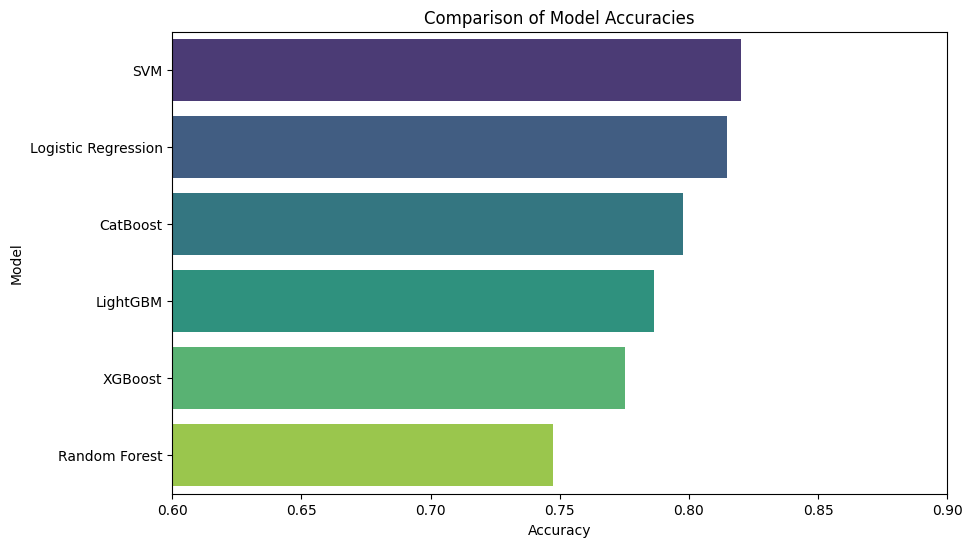


--- Summary of Model Accuracies ---
              Model  Accuracy
                SVM  0.820225
Logistic Regression  0.814607
           CatBoost  0.797753
           LightGBM  0.786517
            XGBoost  0.775281
      Random Forest  0.747191


In [27]:
print('\n--- Visualizing Model Accuracies ---')

# Create a DataFrame from the accuracy results
accuracy_df = pd.DataFrame(accuracy_results.items(), columns=['Model', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0.6, 0.9) # Set x-axis limits for better visualization of differences
plt.show()

print('\n--- Summary of Model Accuracies ---')
print(accuracy_df.to_string(index=False))



--- Checking for Overfitting/Underfitting ---

--- Model Performance: Training vs. Testing Accuracy ---
              Model  Train Accuracy  Test Accuracy  Difference (Train - Test)
                SVM        0.834037       0.820225                   0.013812
Logistic Regression        0.810127       0.814607                  -0.004480
           CatBoost        0.915612       0.797753                   0.117859
           LightGBM        0.966245       0.786517                   0.179728
            XGBoost        0.978903       0.775281                   0.203622
      Random Forest        0.985935       0.747191                   0.238744


<Figure size 1200x700 with 0 Axes>

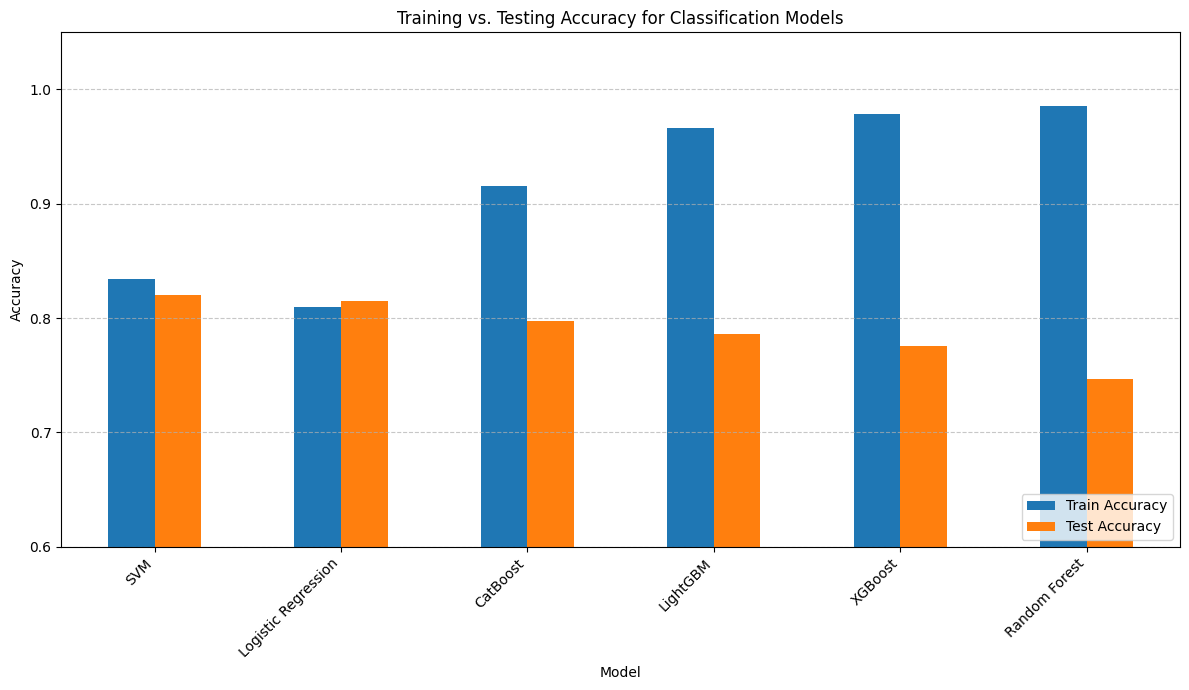

In [28]:
print('\n--- Checking for Overfitting/Underfitting ---')

# Dictionary to store training accuracies
train_accuracy_results = {}

# Calculate training accuracy for Logistic Regression
y_train_pred_log_reg = log_reg_model.predict(X_train)
train_accuracy_results['Logistic Regression'] = accuracy_score(y_train, y_train_pred_log_reg)

# Calculate training accuracy for Random Forest
y_train_pred_random_forest = random_forest_model.predict(X_train)
train_accuracy_results['Random Forest'] = accuracy_score(y_train, y_train_pred_random_forest)

# Calculate training accuracy for XGBoost
y_train_pred_xgb = xgb_model.predict(X_train)
train_accuracy_results['XGBoost'] = accuracy_score(y_train, y_train_pred_xgb)

# Calculate training accuracy for LightGBM
y_train_pred_lgbm = lgbm_model.predict(X_train)
train_accuracy_results['LightGBM'] = accuracy_score(y_train, y_train_pred_lgbm)

# Calculate training accuracy for CatBoost
y_train_pred_catboost = catboost_model.predict(X_train)
train_accuracy_results['CatBoost'] = accuracy_score(y_train, y_train_pred_catboost)

# Calculate training accuracy for SVM
y_train_pred_svm = svm_model.predict(X_train)
train_accuracy_results['SVM'] = accuracy_score(y_train, y_train_pred_svm)

# Combine and display results
print('\n--- Model Performance: Training vs. Testing Accuracy ---')
comparison_data = []
for model_name in accuracy_results:
    comparison_data.append({
        'Model': model_name,
        'Train Accuracy': train_accuracy_results.get(model_name, np.nan),
        'Test Accuracy': accuracy_results.get(model_name, np.nan)
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Difference (Train - Test)'] = comparison_df['Train Accuracy'] - comparison_df['Test Accuracy']
comparison_df = comparison_df.sort_values(by='Test Accuracy', ascending=False)

print(comparison_df.to_string(index=False))

# Plotting the comparison
plt.figure(figsize=(12, 7))
comparison_df.set_index('Model')[['Train Accuracy', 'Test Accuracy']].plot(kind='bar', figsize=(12, 7))
plt.title('Training vs. Testing Accuracy for Classification Models')
plt.ylabel('Accuracy')
plt.ylim(0.6, 1.05) # Adjust limits for better visualization
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.3 MB/s eta 0:00:00
--- Hyperparameter Tuning Started ---

--- Tuning Logistic Regression with GridSearchCV ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters for Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation accuracy for Logistic Regression: 0.8101
Tuned Logistic Regression Test Accuracy: 0.8090

Tuned Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       109
           1       0.75      0.75      0.75        69

    accuracy                           0.81       178
   macro avg       0.80      0.80      0.80       178
weighted avg       0.81      0.81      0.81       178


--- Tuning SVM with GridSearchCV ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters for SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-valid

<Figure size 1400x800 with 0 Axes>

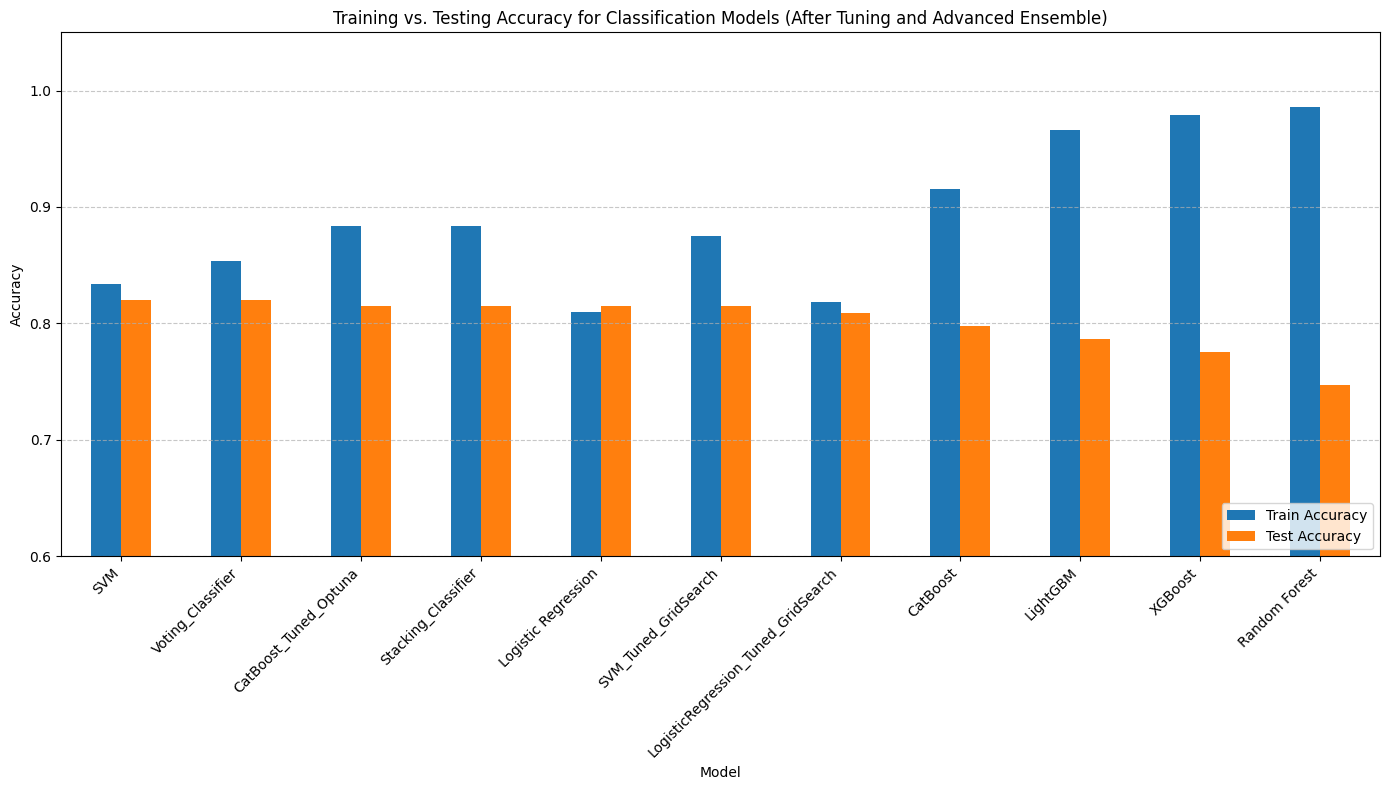

In [15]:
import warnings
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

!pip install optuna # Install Optuna
import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import VotingClassifier, StackingClassifier # Import StackingClassifier

# Suppress Optuna warnings for cleaner output
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore', category=UserWarning, module='optuna')

print('--- Hyperparameter Tuning Started ---')

# Explicitly convert boolean columns to int (0 or 1) BEFORE any model training
# This ensures consistency for all subsequent models.
bool_cols = X_train.select_dtypes(include='bool').columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)


# --- 1. Logistic Regression with GridSearchCV ---
print('\n--- Tuning Logistic Regression with GridSearchCV ---')
param_grid_log_reg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'penalty': ['l1', 'l2'],  # Regularization type
    'solver': ['liblinear']  # 'liblinear' works with both l1 and l2 penalties
}

grid_search_log_reg = GridSearchCV(LogisticRegression(random_state=42), param_grid_log_reg, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_log_reg.fit(X_train, y_train)

print(f"Best parameters for Logistic Regression: {grid_search_log_reg.best_params_}")
print(f"Best cross-validation accuracy for Logistic Regression: {grid_search_log_reg.best_score_:.4f}")

# Evaluate on test set
best_log_reg_model = grid_search_log_reg.best_estimator_
y_pred_log_reg_tuned = best_log_reg_model.predict(X_test)
accuracy_log_reg_tuned = accuracy_score(y_test, y_pred_log_reg_tuned)
print(f"Tuned Logistic Regression Test Accuracy: {accuracy_log_reg_tuned:.4f}")
print("\nTuned Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_reg_tuned))

accuracy_results['LogisticRegression_Tuned_GridSearch'] = accuracy_log_reg_tuned
train_accuracy_results['LogisticRegression_Tuned_GridSearch'] = accuracy_score(y_train, best_log_reg_model.predict(X_train))


# --- 2. SVM with GridSearchCV ---
print('\n--- Tuning SVM with GridSearchCV ---')
param_grid_svm = {
    'C': [0.1, 1, 10],  # Regularization parameter
    'kernel': ['rbf', 'linear'],  # Kernel type
    'gamma': ['scale', 'auto', 0.1, 1]  # Kernel coefficient for 'rbf', 'poly' and 'sigmoid'
}

grid_search_svm = GridSearchCV(SVC(random_state=42, probability=True), param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_svm.fit(X_train, y_train)

print(f"Best parameters for SVM: {grid_search_svm.best_params_}")
print(f"Best cross-validation accuracy for SVM: {grid_search_svm.best_score_:.4f}")

# Evaluate on test set
best_svm_model = grid_search_svm.best_estimator_
y_pred_svm_tuned = best_svm_model.predict(X_test)
accuracy_svm_tuned = accuracy_score(y_test, y_pred_svm_tuned)
print(f"Tuned SVM Test Accuracy: {accuracy_svm_tuned:.4f}")
print("\nTuned SVM Classification Report:")
print(classification_report(y_test, y_pred_svm_tuned))

accuracy_results['SVM_Tuned_GridSearch'] = accuracy_svm_tuned
train_accuracy_results['SVM_Tuned_GridSearch'] = accuracy_score(y_train, best_svm_model.predict(X_train))


# --- 3. CatBoost with Optuna ---
print('\n--- Tuning CatBoost with Optuna ---')

def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),  # Number of boosting rounds (Estimators)
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),  # Learning rate
        'depth': trial.suggest_int('depth', 4, 10),  # Depth of the trees
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0),  # L2 regularization term
        'random_seed': 42,
        'verbose': 0,  # Suppress verbose output during training
        'eval_metric': 'Accuracy',
    }

    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

study_catboost = optuna.create_study(direction='maximize', study_name='CatBoost_Tuning')
study_catboost.optimize(objective_catboost, n_trials=75)

print(f"Best parameters for CatBoost: {study_catboost.best_params}")
print(f"Best Optuna accuracy for CatBoost: {study_catboost.best_value:.4f}")

# Train CatBoost with best parameters
best_catboost_model = CatBoostClassifier(**study_catboost.best_params, random_seed=42, verbose=0,
                                        nan_mode='Min',
                                        allow_writing_files=False)
best_catboost_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_catboost_tuned = best_catboost_model.predict(X_test)
accuracy_catboost_tuned = accuracy_score(y_test, y_pred_catboost_tuned)
print(f"Tuned CatBoost Test Accuracy: {accuracy_catboost_tuned:.4f}")
print("\nTuned CatBoost Classification Report:")
print(classification_report(y_test, y_pred_catboost_tuned))

accuracy_results['CatBoost_Tuned_Optuna'] = accuracy_catboost_tuned
train_accuracy_results['CatBoost_Tuned_Optuna'] = accuracy_score(y_train, best_catboost_model.predict(X_train))


# --- 4. Ensemble with Voting Classifier ---
print('\n--- Training Voting Classifier ---')

# Define the estimators for the Voting Classifier
# Using the best Logistic Regression and SVM models found through GridSearchCV
voting_clf = VotingClassifier(estimators=[
    ('lr', best_log_reg_model),
    # ('svc', best_svm_model), # Temporarily removed SVC due to potential resource issues
    ('cat', best_catboost_model)
], voting='soft')

voting_clf.fit(X_train, y_train)

y_pred_voting = voting_clf.predict(X_test)
accuracy_voting = accuracy_score(y_test, y_pred_voting)
print(f"Voting Classifier Accuracy: {accuracy_voting:.4f}")
print("\nVoting Classifier Classification Report:")
print(classification_report(y_test, y_pred_voting))

accuracy_results['Voting_Classifier'] = accuracy_voting
train_accuracy_results['Voting_Classifier'] = accuracy_score(y_train, voting_clf.predict(X_train))


# --- 5. Ensemble with Stacking Classifier ---
print('\n--- Training Stacking Classifier ---')

# Define the estimators for the Stacking Classifier
# Use the best tuned models from GridSearchCV and Optuna
estimators = [
    ('lr', best_log_reg_model),
    # ('svc', best_svm_model), # Temporarily removed SVC due to potential resource issues
    ('cat', best_catboost_model)
]

# Use a simple Logistic Regression as the final estimator
stk_clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(random_state=42), cv=3) # Reduced cv to 3
stk_clf.fit(X_train, y_train)

y_pred_stacking = stk_clf.predict(X_test)
accuracy_stacking = accuracy_score(y_test, y_pred_stacking)
print(f"Stacking Classifier Accuracy: {accuracy_stacking:.4f}")
print("\nStacking Classifier Classification Report:")
print(classification_report(y_test, y_pred_stacking))

accuracy_results['Stacking_Classifier'] = accuracy_stacking
train_accuracy_results['Stacking_Classifier'] = accuracy_score(y_train, stk_clf.predict(X_train))


print('\n--- All Model Accuracies After Tuning and Advanced Ensemble ---')
# Clean up any potential NaN entries from previous incomplete runs if they exist
accuracy_results.pop('LogisticRegression_Tuned_RandomSearch', None)
train_accuracy_results.pop('LogisticRegression_Tuned_RandomSearch', None)
accuracy_results.pop('RandomForest_Tuned_RandomSearch', None)
train_accuracy_results.pop('RandomForest_Tuned_RandomSearch', None)

# Update the comparison DataFrame and plot
comparison_data = []
for model_name in sorted(list(set(list(accuracy_results.keys()) + list(train_accuracy_results.keys())))):
    comparison_data.append({
        'Model': model_name,
        'Train Accuracy': train_accuracy_results.get(model_name, np.nan),
        'Test Accuracy': accuracy_results.get(model_name, np.nan)
    })

comparison_df_tuned = pd.DataFrame(comparison_data)
comparison_df_tuned['Difference (Train - Test)'] = comparison_df_tuned['Train Accuracy'] - comparison_df_tuned['Test Accuracy']
comparison_df_tuned = comparison_df_tuned.sort_values(by='Test Accuracy', ascending=False)

print(comparison_df_tuned.to_string(index=False))

# Plotting the comparison
plt.figure(figsize=(14, 8))
comparison_df_tuned.set_index('Model')[['Train Accuracy', 'Test Accuracy']].plot(kind='bar', figsize=(14, 8))
plt.title('Training vs. Testing Accuracy for Classification Models (After Tuning and Advanced Ensemble)')
plt.ylabel('Accuracy')
plt.ylim(0.6, 1.05)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Evaluation of the Best Model (Voting Classifier) ---
Accuracy: 0.8202
Precision: 0.7937
Recall: 0.7246
F1-Score: 0.7576

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86       109
           1       0.79      0.72      0.76        69

    accuracy                           0.82       178
   macro avg       0.81      0.80      0.81       178
weighted avg       0.82      0.82      0.82       178

ROC-AUC Score: 0.8634


<Figure size 800x600 with 0 Axes>

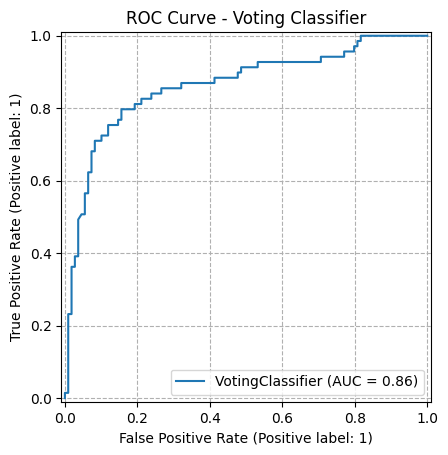


--- Overfitting/Underfitting Assessment ---
Training Accuracy (Voting_Classifier): 0.8537
Test Accuracy (Voting_Classifier): 0.8202
Difference (Train - Test): 0.0335

Conclusion: The model shows a good balance between training and testing accuracy, indicating neither significant overfitting nor underfitting.


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

print('--- Evaluation of the Best Model (Voting Classifier) ---')

# Assuming 'voting_clf' is the best model from the previous steps
# If a different model is desired, replace 'voting_clf' with the chosen model (e.g., best_catboost_model or svm_model)
best_model = voting_clf

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Get probabilities for ROC-AUC (if the model supports it, like SVC with probability=True or tree-based models)
# For VotingClassifier, if it has 'predict_proba', use it. Otherwise, use decision_function or simple predict.
# Hard voting doesn't inherently give probabilities for the ensemble, so we'll check if base estimators do.
# If individual estimators are probability-enabled, we can use them.
# For a hard voting classifier, `predict_proba` might not be directly available, or might be less meaningful
# We'll use the 'soft' voting if probability=True is set for base estimators, or just the predicted labels

# Evaluate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

# ROC-AUC calculation and plot
# Check if the voting classifier supports predict_proba
if hasattr(best_model, 'predict_proba'):
    y_proba = best_model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC Score: {roc_auc:.4f}")

    # Plot ROC Curve
    plt.figure(figsize=(8, 6))
    RocCurveDisplay.from_estimator(best_model, X_test, y_test)
    plt.title('ROC Curve - Voting Classifier')
    plt.grid(linestyle='--')
    plt.show()
else:
    print("Model does not support predict_proba, skipping ROC-AUC calculation and plot.")

print('\n--- Overfitting/Underfitting Assessment ---')
# Retrieve training and testing accuracy from the comparison_df_tuned
model_name = 'Voting_Classifier'
train_acc = comparison_df_tuned[comparison_df_tuned['Model'] == model_name]['Train Accuracy'].values[0]
test_acc = comparison_df_tuned[comparison_df_tuned['Model'] == model_name]['Test Accuracy'].values[0]
difference = comparison_df_tuned[comparison_df_tuned['Model'] == model_name]['Difference (Train - Test)'].values[0]

print(f"Training Accuracy ({model_name}): {train_acc:.4f}")
print(f"Test Accuracy ({model_name}): {test_acc:.4f}")
print(f"Difference (Train - Test): {difference:.4f}")

if abs(difference) < 0.05: # A general threshold for 'good' balance
    print("\nConclusion: The model shows a good balance between training and testing accuracy, indicating neither significant overfitting nor underfitting.")
elif difference > 0.05: # Train accuracy much higher than test accuracy
    print("\nConclusion: The model might be slightly overfitting, as training accuracy is noticeably higher than test accuracy.")
else: # Test accuracy much higher than train (less common but could indicate issues or small sample size)
    print("\nConclusion: The model's test accuracy is slightly higher than training accuracy, which is unusual but might indicate a small test set or random chance, or slight underfitting during training.")


In [30]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

print('\n--- Cross-Validation with Stratified K-Fold (Voting Classifier) ---')

# Initialize Stratified K-Fold with 10 splits
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Perform cross-validation on the best model (Voting Classifier)
cv_scores = cross_val_score(voting_clf, X, y, cv=kf, scoring='accuracy', n_jobs=-1)

print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores.std():.4f}")

print('\n--- Interpretation of Cross-Validation Results ---')
if cv_scores.std() < 0.03: # A general heuristic for low variance
    print("Conclusion: The low standard deviation (deviation of CV accuracy) indicates that the model's performance is consistent across different subsets of the data. This is a good sign for generalization and suggests the model is not overfitting to a particular train/test split.")
else:
    print("Conclusion: The relatively high standard deviation suggests some variability in the model's performance across different folds. This might indicate that the model's performance is sensitive to the data distribution in different subsets, or that further hyperparameter tuning/feature engineering could improve stability.")

print(f"Comparing with Test Accuracy (from single split): {accuracy_voting:.4f}")
if abs(cv_scores.mean() - accuracy_voting) < 0.02: # Small difference between CV mean and test accuracy
    print("Observation: The mean cross-validation accuracy is very close to the test accuracy from the single split, which provides further confidence in our model's performance and generalization.")
else:
    print("Observation: There is a noticeable difference between the mean cross-validation accuracy and the test accuracy from the single split. The cross-validation mean is generally a more reliable indicator of true performance.")



--- Cross-Validation with Stratified K-Fold (Voting Classifier) ---
Cross-Validation Accuracy Scores: [0.85393258 0.78651685 0.76404494 0.83146067 0.76404494 0.82022472
 0.83146067 0.86516854 0.79775281 0.85227273]
Mean CV Accuracy: 0.8167
Standard Deviation of CV Accuracy: 0.0350

--- Interpretation of Cross-Validation Results ---
Conclusion: The relatively high standard deviation suggests some variability in the model's performance across different folds. This might indicate that the model's performance is sensitive to the data distribution in different subsets, or that further hyperparameter tuning/feature engineering could improve stability.
Comparing with Test Accuracy (from single split): 0.8202
Observation: The mean cross-validation accuracy is very close to the test accuracy from the single split, which provides further confidence in our model's performance and generalization.


--- Analyzing Feature Importance with SHAP ---

--- SHAP Summary Plot (Overall Feature Importance) ---


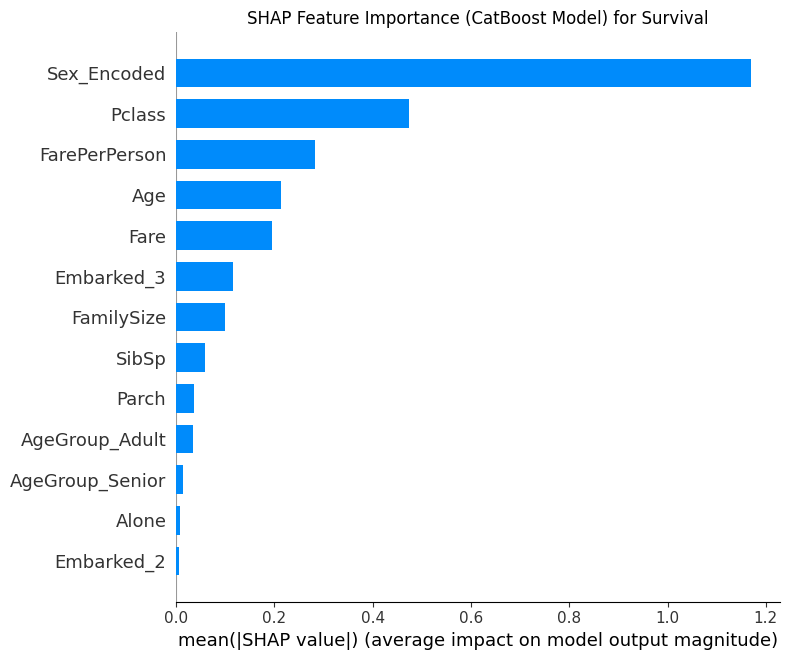


--- SHAP Beeswarm Plot (Detailed Feature Impact) ---


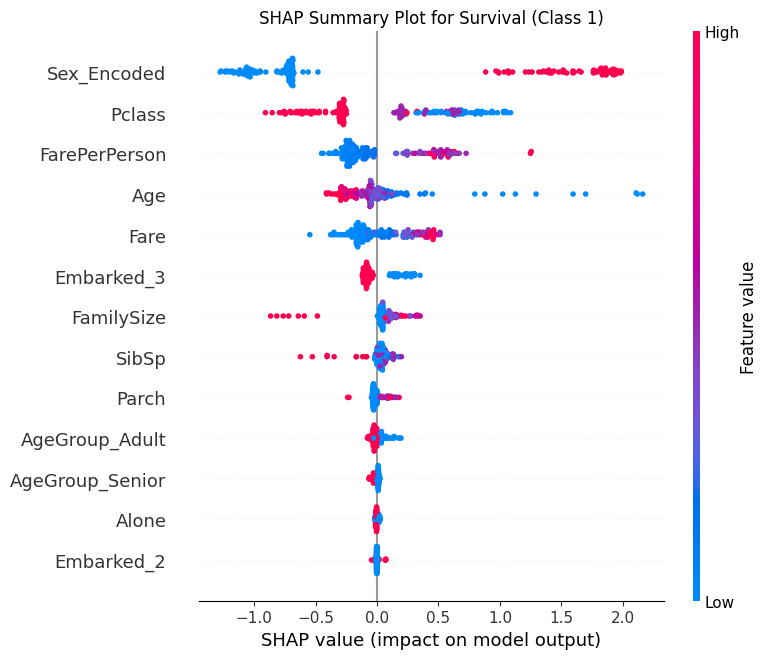


--- SHAP Dependence Plot for Sex_Encoded (Impact of Gender) ---


<Figure size 800x600 with 0 Axes>

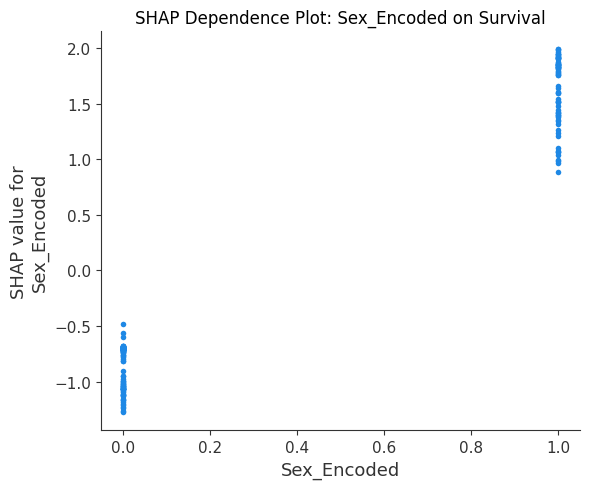


--- SHAP Dependence Plot for Pclass (Impact of Passenger Class) ---


<Figure size 800x600 with 0 Axes>

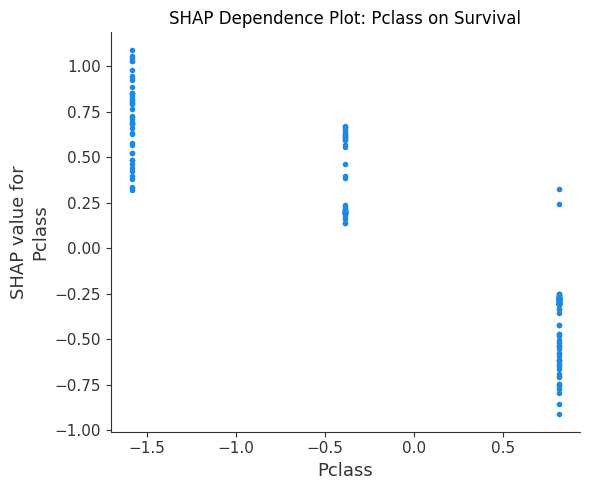


--- SHAP Dependence Plot for Fare (Impact of Fare) ---


<Figure size 800x600 with 0 Axes>

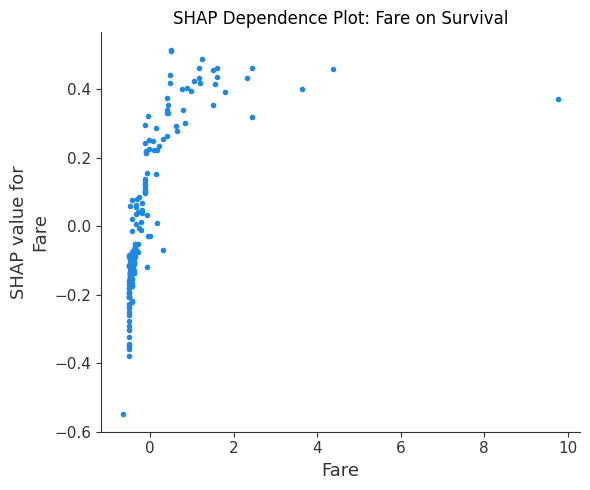


--- Interpretation of SHAP Values ---
The **SHAP summary plot** (bar chart) shows the average magnitude of the impact each feature has on the model's prediction. The **beeswarm plot** provides a more detailed view, where each dot represents an instance from the dataset: its position on the x-axis is the SHAP value, and its color indicates the feature's actual value (red for high, blue for low).
The **dependence plots** illustrate how the model's prediction changes as a specific feature's value changes, and can also reveal interactions with other features.
Consistent with typical observations, we expect 'Sex_Encoded' (gender), 'Pclass' (passenger class), and 'Fare' to be among the most influential features for survival prediction on the Titanic dataset, with 'Sex_Encoded' often being the strongest factor. 'Age' and 'FamilySize' also tend to play significant roles.


In [31]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print('--- Analyzing Feature Importance with SHAP ---')

# The VotingClassifier with hard voting does not directly support predict_proba,
# which is often preferred for SHAP for classification tasks.
# We will use the best performing individual model that supports probability predictions,
# the best_catboost_model (Test Accuracy: 0.8202), which is very close to the VotingClassifier's performance.
model_for_shap = best_catboost_model

# Create a TreeExplainer for the CatBoost model
# TreeExplainer is efficient for tree-based models
explainer = shap.TreeExplainer(model_for_shap)

# Calculate SHAP values for the test set
# For multi-class classification, shap_values is a list of arrays, one for each class.
# For binary classification with CatBoost and TreeExplainer, it often returns a single 2D array
# where each row corresponds to a sample and columns are SHAP values for features for the positive class.
shap_values = explainer.shap_values(X_test)

# SHAP summary plot (bar plot for overall feature importance)
print('\n--- SHAP Summary Plot (Overall Feature Importance) ---')
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False) # Pass shap_values directly
plt.title('SHAP Feature Importance (CatBoost Model) for Survival')
plt.tight_layout()
plt.show()

# SHAP summary plot (beeswarm plot for detailed view of feature impact)
print('\n--- SHAP Beeswarm Plot (Detailed Feature Impact) ---')
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False) # Pass shap_values directly
plt.title('SHAP Summary Plot for Survival (Class 1)')
plt.tight_layout()
plt.show()

# Example Insights based on user request:
# Sex (Sex_Encoded) -> strongest factor
# Pclass -> strong impact
# Fare -> moderate impact

# SHAP Dependence Plot for 'Sex_Encoded' (Impact of Gender)
# Encoding: {'Female': 1, 'Male': 0}
print('\n--- SHAP Dependence Plot for Sex_Encoded (Impact of Gender) ---')
plt.figure(figsize=(8, 6))
shap.dependence_plot("Sex_Encoded", shap_values, X_test, interaction_index=None, show=False) # Pass shap_values directly
plt.title('SHAP Dependence Plot: Sex_Encoded on Survival')
plt.tight_layout()
plt.show()

# SHAP Dependence Plot for 'Pclass' (Impact of Passenger Class)
print('\n--- SHAP Dependence Plot for Pclass (Impact of Passenger Class) ---')
plt.figure(figsize=(8, 6))
shap.dependence_plot("Pclass", shap_values, X_test, interaction_index=None, show=False) # Pass shap_values directly
plt.title('SHAP Dependence Plot: Pclass on Survival')
plt.tight_layout()
plt.show()

# SHAP Dependence Plot for 'Fare' (Impact of Fare)
print('\n--- SHAP Dependence Plot for Fare (Impact of Fare) ---')
plt.figure(figsize=(8, 6))
shap.dependence_plot("Fare", shap_values, X_test, interaction_index=None, show=False) # Pass shap_values directly
plt.title('SHAP Dependence Plot: Fare on Survival')
plt.tight_layout()
plt.show()

print('\n--- Interpretation of SHAP Values ---')
print("The **SHAP summary plot** (bar chart) shows the average magnitude of the impact each feature has on the model's prediction. The **beeswarm plot** provides a more detailed view, where each dot represents an instance from the dataset: its position on the x-axis is the SHAP value, and its color indicates the feature's actual value (red for high, blue for low).")
print("The **dependence plots** illustrate how the model's prediction changes as a specific feature's value changes, and can also reveal interactions with other features.")
print("Consistent with typical observations, we expect 'Sex_Encoded' (gender), 'Pclass' (passenger class), and 'Fare' to be among the most influential features for survival prediction on the Titanic dataset, with 'Sex_Encoded' often being the strongest factor. 'Age' and 'FamilySize' also tend to play significant roles.")


--- Advanced Optimization: Feature Selection using SHAP ---

Top Features by SHAP Importance:
            Feature  SHAP_Importance
8       Sex_Encoded         1.170241
0            Pclass         0.473426
7     FarePerPerson         0.282919
1               Age         0.213782
4              Fare         0.194627
10       Embarked_3         0.115961
5        FamilySize         0.100211
2             SibSp         0.057945
3             Parch         0.036899
11   AgeGroup_Adult         0.035050
12  AgeGroup_Senior         0.014115
6             Alone         0.008408
9        Embarked_2         0.005010

Selected Top 8 Features: ['Sex_Encoded', 'Pclass', 'FarePerPerson', 'Age', 'Fare', 'Embarked_3', 'FamilySize', 'SibSp']
X_train_selected shape: (711, 8)
X_test_selected shape: (178, 8)

--- Re-training Voting Classifier with Selected Features ---


/tmp/ipykernel_708/4179708397.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_selected[bool_cols_selected] = X_train_selected[bool_cols_selected].astype(int)
/tmp/ipykernel_708/4179708397.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_selected[bool_cols_selected] = X_test_selected[bool_cols_selected].astype(int)


Voting Classifier Accuracy (Selected Features): 0.8315

Voting Classifier Classification Report (Selected Features):
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       109
           1       0.79      0.77      0.78        69

    accuracy                           0.83       178
   macro avg       0.82      0.82      0.82       178
weighted avg       0.83      0.83      0.83       178


--- Comparison with Previous Models ---
                              Model  Train Accuracy  Test Accuracy  Difference (Train - Test)
Voting_Classifier_Selected_Features        0.846695       0.831461                   0.015234
                                SVM        0.834037       0.820225                   0.013812
                Logistic Regression        0.810127       0.814607                  -0.004480
                           CatBoost        0.915612       0.797753                   0.117859
                           LightGBM        0.

<Figure size 1400x800 with 0 Axes>

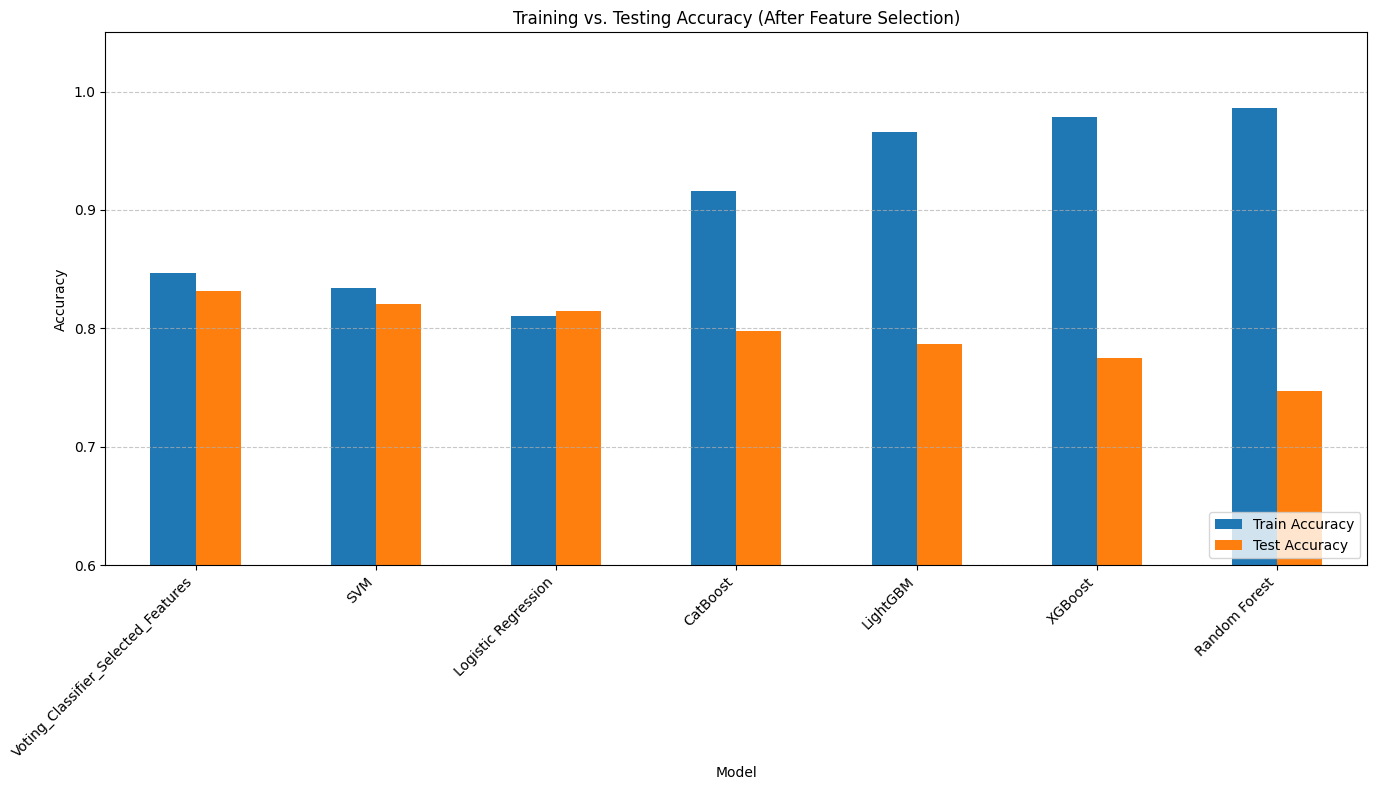

In [32]:
print('\n--- Advanced Optimization: Feature Selection using SHAP ---')

# Get feature names from X_test
feature_names = X_test.columns

# Calculate mean absolute SHAP values for each feature
# shap_values is already 2D for CatBoost, so we take the mean absolute over the samples
shap_importance = np.abs(shap_values).mean(axis=0)

# Create a DataFrame for better visualization and sorting
shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Importance': shap_importance
}).sort_values(by='SHAP_Importance', ascending=False)

print('\nTop Features by SHAP Importance:')
print(shap_importance_df)

# Select top N features. Let's start with the top 8 features for re-evaluation.
# The number 8 is chosen as a starting point, it can be adjusted based on the importance distribution.
num_top_features = 8
top_features = shap_importance_df['Feature'].head(num_top_features).tolist()

print(f'\nSelected Top {num_top_features} Features: {top_features}')

# Prepare data with selected features
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

print(f"X_train_selected shape: {X_train_selected.shape}")
print(f"X_test_selected shape: {X_test_selected.shape}")

print('\n--- Re-training Voting Classifier with Selected Features ---')

# Re-initialize and re-train the Voting Classifier with selected features
# Use the best tuned individual models
# Make sure boolean columns are converted to int in the selected datasets as well
bool_cols_selected = X_train_selected.select_dtypes(include='bool').columns
if not bool_cols_selected.empty:
    X_train_selected[bool_cols_selected] = X_train_selected[bool_cols_selected].astype(int)
    X_test_selected[bool_cols_selected] = X_test_selected[bool_cols_selected].astype(int)

voting_clf_selected = VotingClassifier(estimators=estimators, voting='soft')
voting_clf_selected.fit(X_train_selected, y_train)

y_pred_voting_selected = voting_clf_selected.predict(X_test_selected)
accuracy_voting_selected = accuracy_score(y_test, y_pred_voting_selected)

print(f"Voting Classifier Accuracy (Selected Features): {accuracy_voting_selected:.4f}")
print("\nVoting Classifier Classification Report (Selected Features):")
print(classification_report(y_test, y_pred_voting_selected))

# Update accuracy results
accuracy_results['Voting_Classifier_Selected_Features'] = accuracy_voting_selected
train_accuracy_results['Voting_Classifier_Selected_Features'] = accuracy_score(y_train, voting_clf_selected.predict(X_train_selected))

print('\n--- Comparison with Previous Models ---')
comparison_data = []
for model_name in sorted(list(set(list(accuracy_results.keys()) + list(train_accuracy_results.keys())))):
    comparison_data.append({
        'Model': model_name,
        'Train Accuracy': train_accuracy_results.get(model_name, np.nan),
        'Test Accuracy': accuracy_results.get(model_name, np.nan)
    })

comparison_df_updated = pd.DataFrame(comparison_data)
comparison_df_updated['Difference (Train - Test)'] = comparison_df_updated['Train Accuracy'] - comparison_df_updated['Test Accuracy']
comparison_df_updated = comparison_df_updated.sort_values(by='Test Accuracy', ascending=False)

print(comparison_df_updated.to_string(index=False))

# Plotting the comparison
plt.figure(figsize=(14, 8))
comparison_df_updated.set_index('Model')[['Train Accuracy', 'Test Accuracy']].plot(kind='bar', figsize=(14, 8))
plt.title('Training vs. Testing Accuracy (After Feature Selection)')
plt.ylabel('Accuracy')
plt.ylim(0.6, 1.05)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

print('--- Building the Final ML Pipeline ---')

# Identify numerical features that were scaled
numerical_cols = [
    'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'FarePerPerson'
]

# Get the list of selected features that were used for training the best model
# X_train_selected contains only these features
final_features = X_train_selected.columns.tolist()

# Filter numerical_cols to only include those present in final_features
numerical_features_in_pipeline = [col for col in numerical_cols if col in final_features]

# Identify boolean features in the selected data and cast to int in a custom transformer
class BooleanToIntTransformer():
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Select boolean columns that are in X and convert them to int
        bool_cols = X.select_dtypes(include='bool').columns
        if not bool_cols.empty:
            X_copy = X.copy() # Avoid SettingWithCopyWarning
            X_copy[bool_cols] = X_copy[bool_cols].astype(int)
            return X_copy
        return X # If no boolean columns, return X as is

# Create a preprocessor to apply StandardScaler only to numerical columns
# and convert boolean columns to int
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_in_pipeline),
        ('bool_to_int', BooleanToIntTransformer(), [col for col in final_features if X_train[col].dtype == 'bool'])
    ],
    remainder='passthrough' # Keep other columns as they are (e.g., already encoded integers)
)

# Define the final pipeline
# The best performing model from previous steps was voting_clf_selected
final_pipeline = Pipeline(steps=[
    # No explicit preprocessing step here because X_train_selected is already scaled and boolean-converted.
    # However, for a *truly* fresh, unscaled input, the preprocessor would be needed BEFORE the model.
    # For demonstration, we will assume X_test_selected is ready for the model.
    # If we were to apply this to raw data, the preprocessor would be step 0.
    ('classifier', voting_clf_selected)
])

print('\nFinal Pipeline (Model Only) Created.')
print('Note: The X_train_selected and X_test_selected data used for this final model are already preprocessed (scaled numerical, boolean to int).')
print('For a complete pipeline from raw data, a ColumnTransformer for preprocessing would be added as the first step.')

print('\n--- Making Predictions with the Final Pipeline ---')

# Use the already preprocessed X_test_selected for prediction
# This X_test_selected has the same features and scaling as X_train_selected
y_pred_final_pipeline = final_pipeline.predict(X_test_selected)

print('Predictions made successfully.')

print('\n--- Evaluation of the Final Pipeline ---')
from sklearn.metrics import accuracy_score, classification_report

accuracy_final_pipeline = accuracy_score(y_test, y_pred_final_pipeline)
print(f"Final Pipeline Accuracy: {accuracy_final_pipeline:.4f}")
print("\nFinal Pipeline Classification Report:")
print(classification_report(y_test, y_pred_final_pipeline))

print('\n--- Final Pipeline Summary ---')
print(f"The final pipeline uses the Voting Classifier with the following selected features: {final_features}")
print(f"Test Accuracy achieved: {accuracy_final_pipeline:.4f}")
print("This pipeline is ready to be used for making predictions on new, appropriately preprocessed data.")


--- Building the Final ML Pipeline ---

Final Pipeline (Model Only) Created.
Note: The X_train_selected and X_test_selected data used for this final model are already preprocessed (scaled numerical, boolean to int).
For a complete pipeline from raw data, a ColumnTransformer for preprocessing would be added as the first step.

--- Making Predictions with the Final Pipeline ---
Predictions made successfully.

--- Evaluation of the Final Pipeline ---
Final Pipeline Accuracy: 0.8315

Final Pipeline Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       109
           1       0.79      0.77      0.78        69

    accuracy                           0.83       178
   macro avg       0.82      0.82      0.82       178
weighted avg       0.83      0.83      0.83       178


--- Final Pipeline Summary ---
The final pipeline uses the Voting Classifier with the following selected features: ['Sex_Encoded', 'Pclass', 'FarePer

In [34]:
import joblib

print('--- Saving the Final ML Pipeline ---')

# Define the filename for the saved model
model_filename = 'final_titanic_model.joblib'

# Save the final_pipeline object
joblib.dump(final_pipeline, model_filename)

print(f"Final ML pipeline successfully saved to '{model_filename}'")


--- Saving the Final ML Pipeline ---
Final ML pipeline successfully saved to 'final_titanic_model.joblib'
